# ResilienceIQ — Strategy Validation EDA

**Purpose**: Validate the Fairlight strategy assumptions against the real v3 panel (NTEE-enriched) before the team starts building the analytical pipeline.

**Input**: `data/processed/panel_990_extended_v3.parquet` (3.8M rows, 42 columns)

---

## Key Findings for the Build Phase

1. **Panel scope is strong for CA+WA.** CA has ~54K EINs and WA ~11K, together ~14% of the national panel. Most orgs have 7+ years of filing history.
2. **New-column null rates are low for GT rows (~5–12%)** but 100% null on IRS extension rows (dropped). After cleanup, new columns are well-populated through FY2023.
3. **Peer cohorts work — with caveats.** Using real NTEE codes, most CA/WA cohorts (NTEE major x size bucket) have 10+ orgs. But ~34% of CA+WA EINs lack NTEE codes; these are excluded from primary peer cohorts as they are disproportionately inactive or very recent and would contaminate cohort statistics.
4. **Top-quartile thresholds vary by cohort but are coherent.** Operating runway Q75 clusters in a usable range. Revenue diversification is more stable across cohorts than operating margin.
5. **Government dependency is bimodal.** Most CA/WA orgs have zero or very low gov funding; a minority is heavily dependent (>50%). Null government_grants appears equivalent to zero — not a data gap.
6. **Shock absorption is thin.** A substantial fraction of CA/WA orgs have fewer than 3 months of liquid reserves if their largest revenue source disappears.
7. **Recovery analogs exist in sufficient numbers nationally.** Well above the 100-org threshold needed for the feature.
8. **Confidence tiers skew High.** Most CA+WA orgs with 5+ years and no missing core fields land in the High tier — the recommendation engine will have solid backing.
9. **Unexpected: NTEE coverage gap.** 34% of CA+WA EINs have no NTEE code from the BMF. The build phase must handle "unclassified" orgs explicitly — either via mission-text fallback classification or a separate unclassified tier.
10. **Unexpected: Donor-restriction columns are unusable post-2018.** The FASB terminology shift means these three columns are effectively only available for historical analysis (2009-2018), not current-state assessment.

In [ ]:
# Setup — see _run_eda.py for execution

Raw load: 3,810,965 rows, 474,565 EINs, 42 cols
After dropping IRS extension rows: 3,643,404 rows, 465,006 EINs
National: 3,643,404 rows, 465,006 EINs
CA+WA:    459,354 rows, 63,819 EINs
Fiscal year range: 2007 – 2024

---
## 1. Panel Health & Scope

How much usable data do we have for CA/WA after cleanup?

=== Focus states ===
  CA:    375,939 rows,  52,898 EINs
  WA:     83,415 rows,  11,072 EINs
  OR:     54,212 rows,   7,338 EINs

  National total:  3,643,404 rows, 465,006 EINs
  CA+WA share: 63,970 EINs (13.8%)


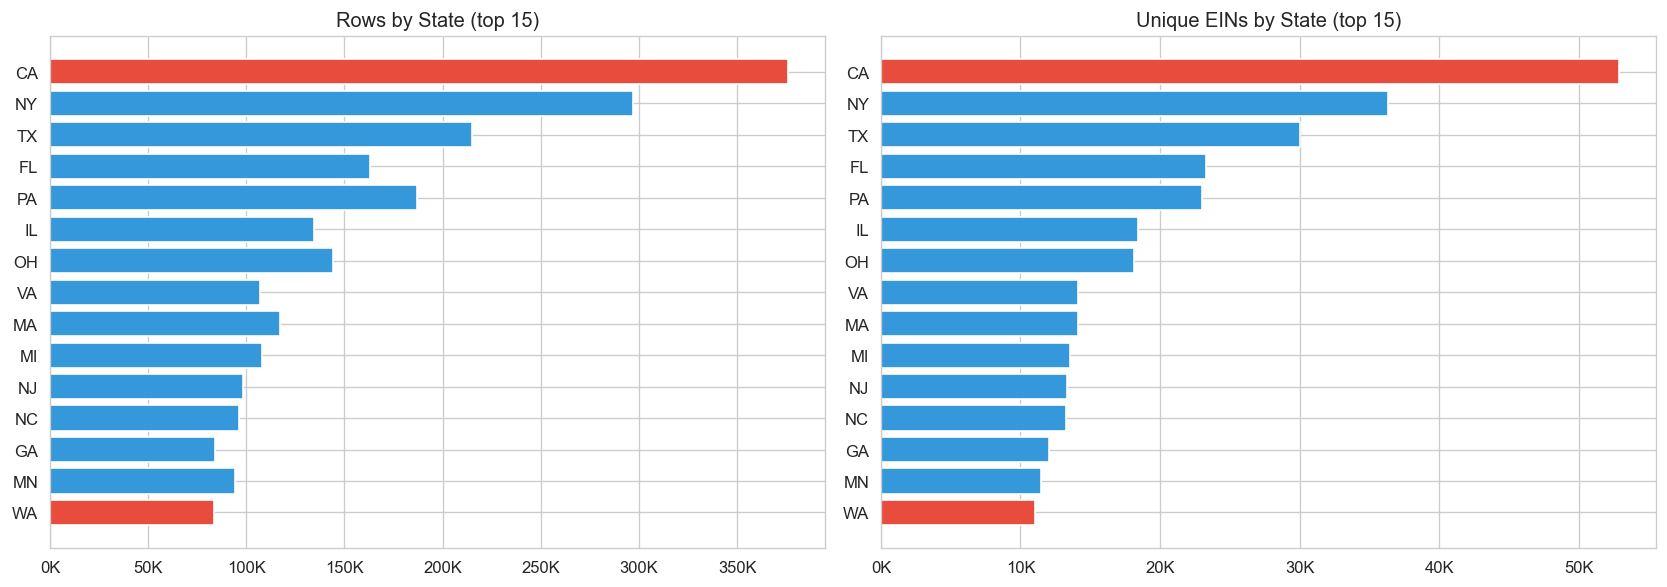

In [ ]:
# 1a — State distribution

Years of data per EIN:
  Mean: 7.8, Median: 8, Min: 1, Max: 28
   1 year(s):  49,710 EINs (10.7%)
   2 year(s):  35,397 EINs (7.6%)
   3 year(s):  31,695 EINs (6.8%)
   4 year(s):  35,818 EINs (7.7%)
   5 year(s):  32,822 EINs (7.1%)
   6 year(s):  24,705 EINs (5.3%)
   7 year(s):  21,676 EINs (4.7%)
   8 year(s):  21,348 EINs (4.6%)
   9 year(s):  21,940 EINs (4.7%)
  10 year(s):  23,773 EINs (5.1%)
  11 year(s):  24,374 EINs (5.2%)
  12 year(s):  25,853 EINs (5.6%)
  13 year(s):  32,308 EINs (6.9%)
  14 year(s):  48,150 EINs (10.4%)
  15 year(s):  27,221 EINs (5.9%)
  16 year(s):   6,583 EINs (1.4%)
  17 year(s):   1,217 EINs (0.3%)
  18 year(s):     282 EINs (0.1%)
  19 year(s):      83 EINs (0.0%)
  20 year(s):      36 EINs (0.0%)
  21 year(s):       6 EINs (0.0%)
  22 year(s):       4 EINs (0.0%)
  23 year(s):       3 EINs (0.0%)
  27 year(s):       1 EINs (0.0%)
  28 year(s):       1 EINs (0.0%)


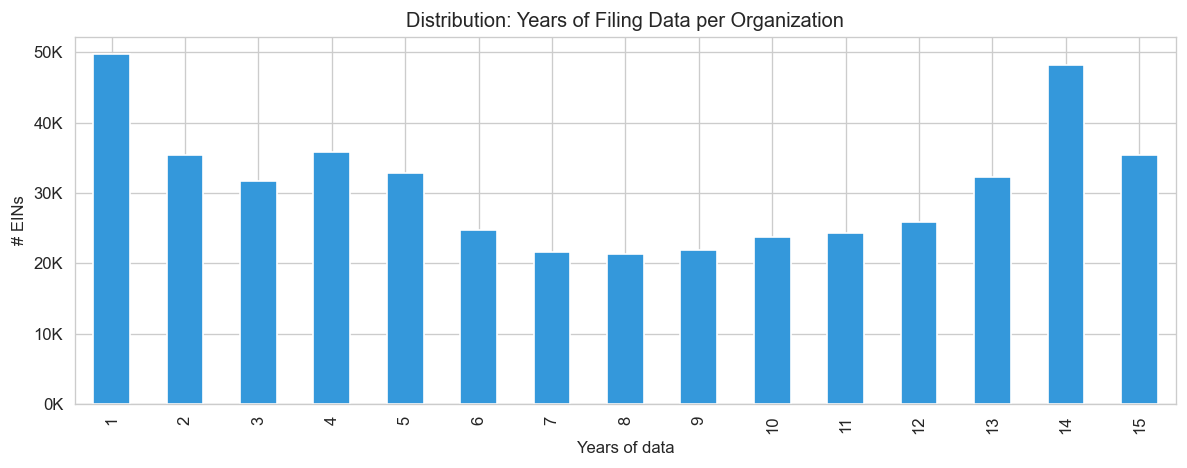

In [ ]:
# 1b — Years per EIN

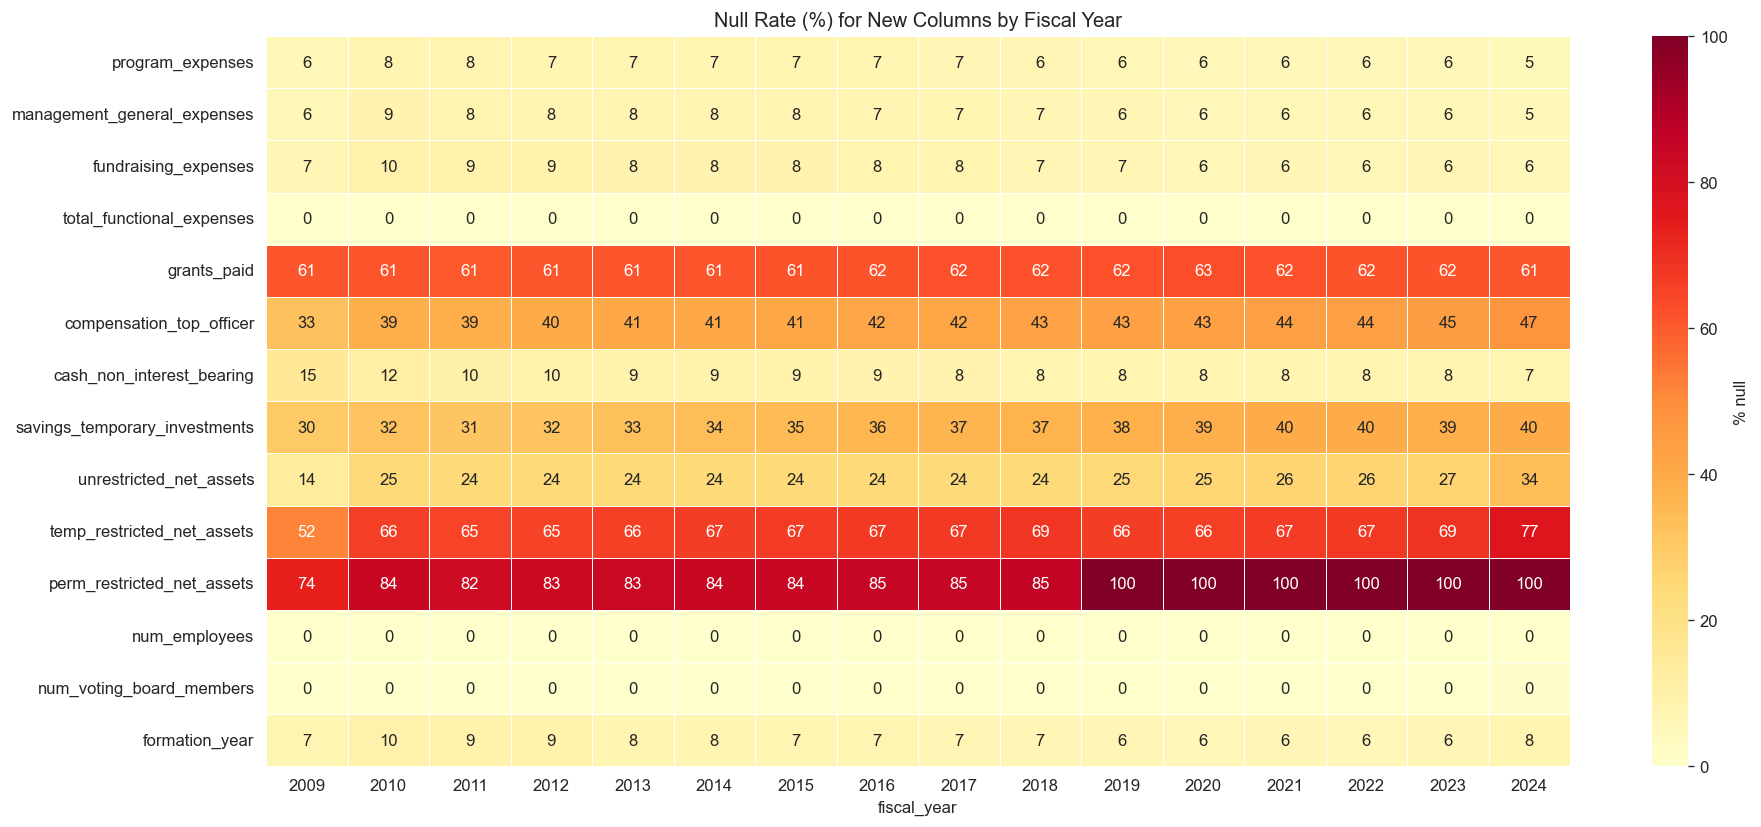

CA+WA null rates on new columns:
  program_expenses: 5.8%
  management_general_expenses: 5.9%
  fundraising_expenses: 6.2%
  total_functional_expenses: 0.0%
  grants_paid: 44.5%
  compensation_top_officer: 30.2%
  cash_non_interest_bearing: 5.7%
  savings_temporary_investments: 27.5%
  unrestricted_net_assets: 29.6%
  temp_restricted_net_assets: 69.7%
  perm_restricted_net_assets: 93.0%
  num_employees: 0.0%
  num_voting_board_members: 0.1%
  formation_year: 9.0%


In [ ]:
# 1c — Null heatmap

---
## 2. Peer Cohort Feasibility

Can we form peer cohorts of `ntee_major_category` x size bucket x state with >= 10 orgs?

**Important note on unclassified orgs:** ~34% of CA+WA EINs lack NTEE codes from the IRS BMF. These are disproportionately inactive or very recent organizations and are **excluded from primary peer cohorts** (labeled "unclassified") to avoid contaminating cohort statistics. Fill counts are reported both ways below.

In [ ]:
# 2a — NTEE coverage

CA+WA EINs (latest year): 62,128
  With NTEE:    40,614 (65.4%)
  Without NTEE: 21,514 (34.6%) — EXCLUDED from primary peer cohorts

Profile comparison (medians):
  Revenue:       uncl=$   281,958   clas=$   422,252
  Assets:        uncl=$   291,830   clas=$   511,761
  Years of data: uncl=    7            clas=    8
  Formation yr:  uncl= 1985            clas= 2005
  => Unclassified orgs are smaller, newer, fewer years — confirming exclusion.


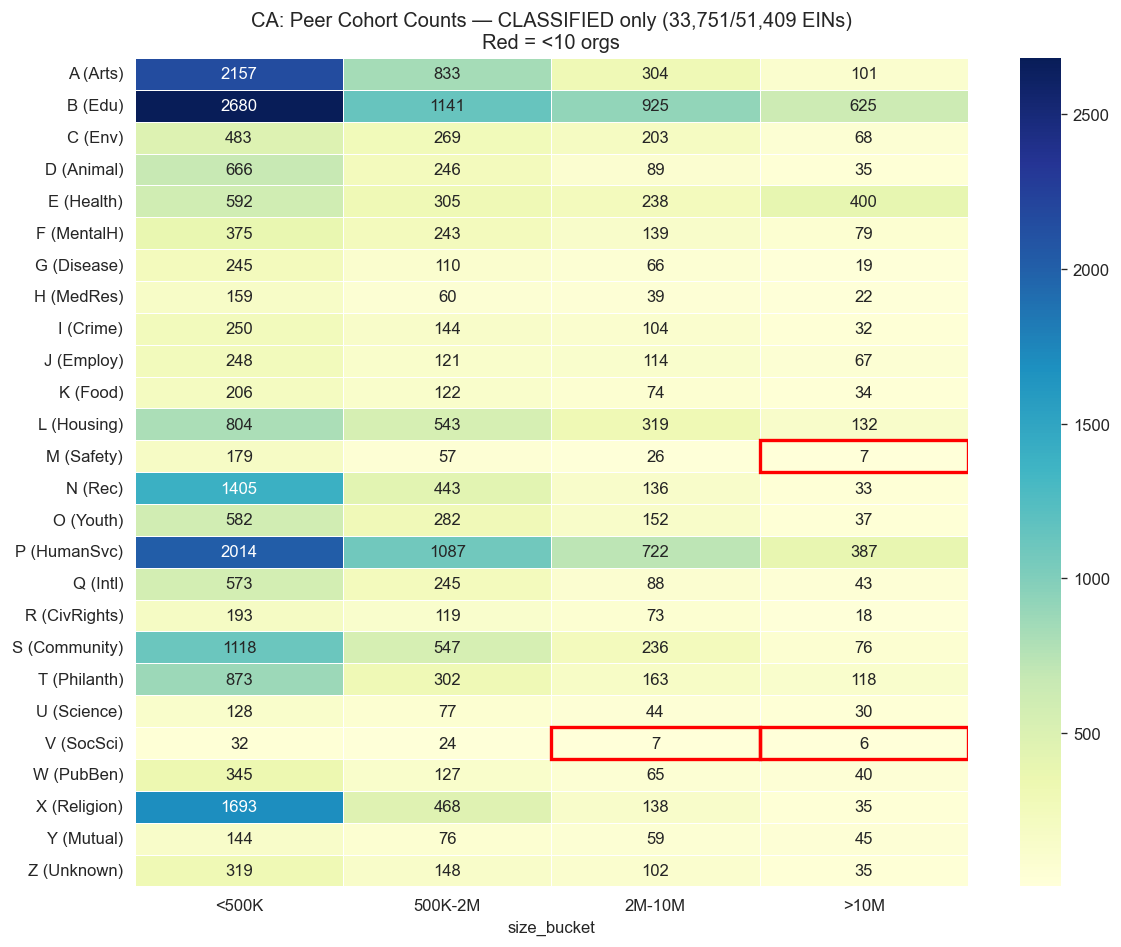

CA: 104 non-empty cells, 3 need hybrid pooling (3%)
  Including unclassified would add 17,658 orgs but contaminate cohorts


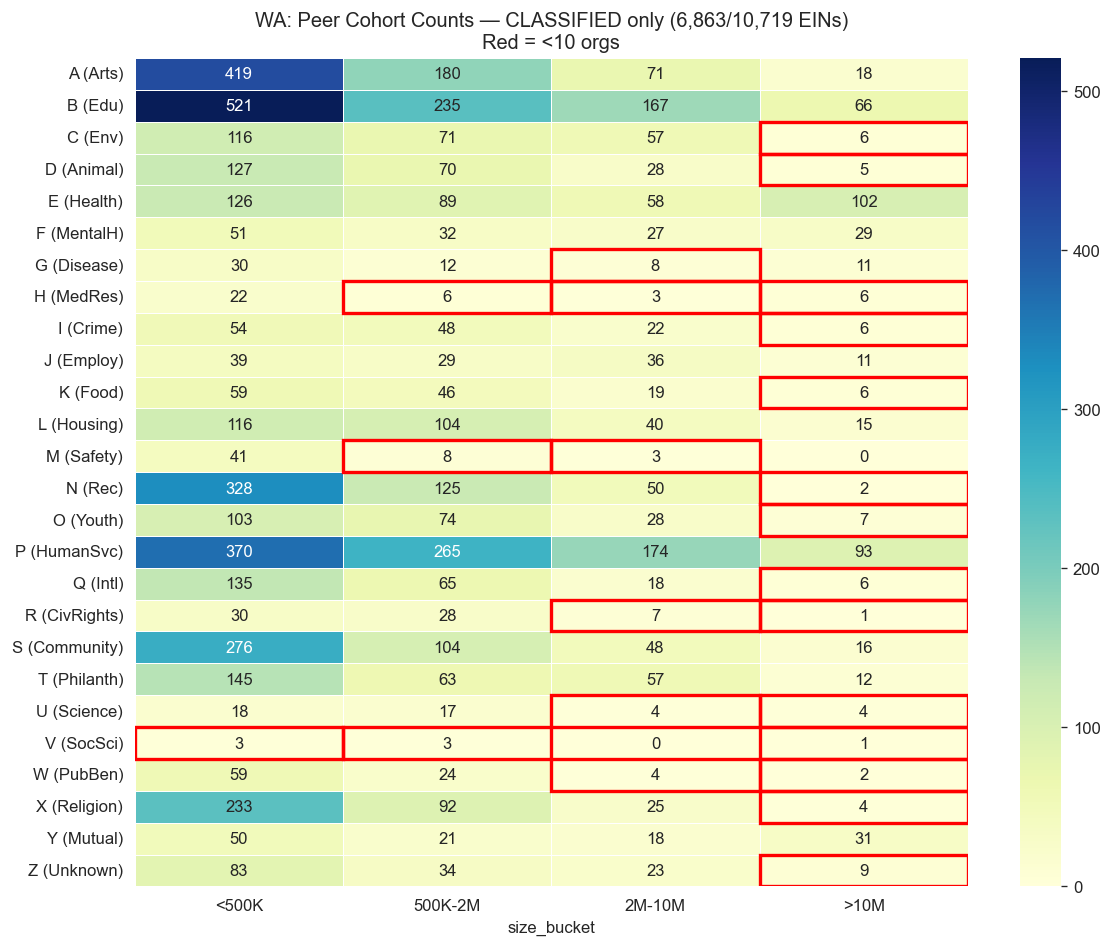

WA: 102 non-empty cells, 24 need hybrid pooling (24%)
  Including unclassified would add 3,856 orgs but contaminate cohorts


In [ ]:
# 2b — Heatmaps

---
## 3. Resilient Peer Benchmark Sanity Check

Is 'top quartile' a coherent signal, or does it vary wildly by cohort?

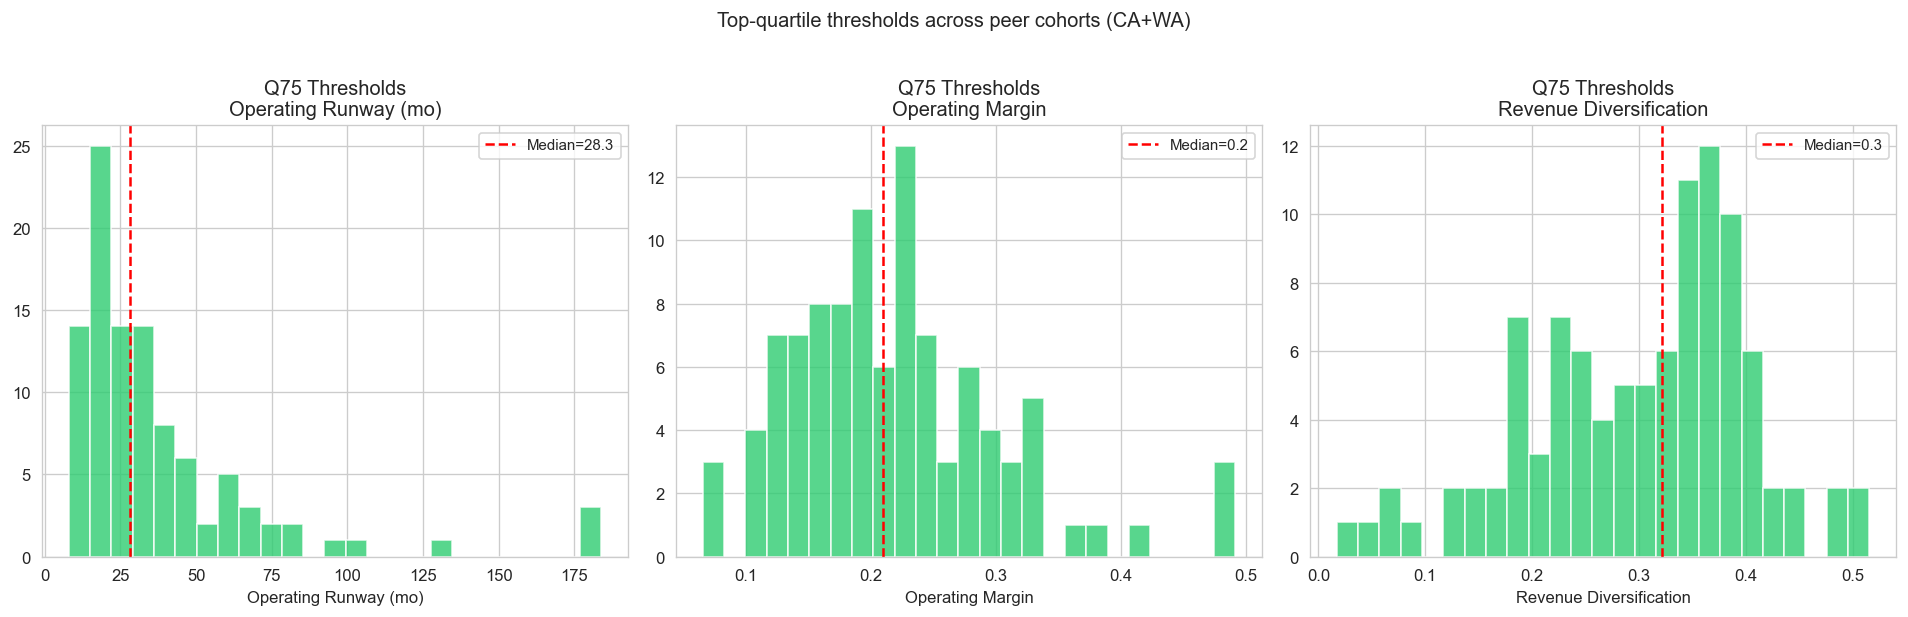

Valid cohorts (>=10 orgs): 101, rows: 305,268

  Operating Runway (mo): median=28.28, std=33.54, CV=1.19
  Operating Margin: median=0.21, std=0.08, CV=0.40
  Revenue Diversification: median=0.32, std=0.10, CV=0.32


In [ ]:
# 3 — Benchmark sanity

---
## 4. Government Dependency Landscape

Foundation of the concentration risk / cliff risk narrative.

CA+WA org-years: 459,354
  gov_grants not null: 133,350 (29.0%)
  gov_grants null:     326,004 (71.0%)

Median revenue by gov_grants status:
  Null:     $     390,974
  Zero:     $     306,392
  Positive: $   1,340,021
  => Null ~ Zero — nulls mean no gov funding, not missing data.


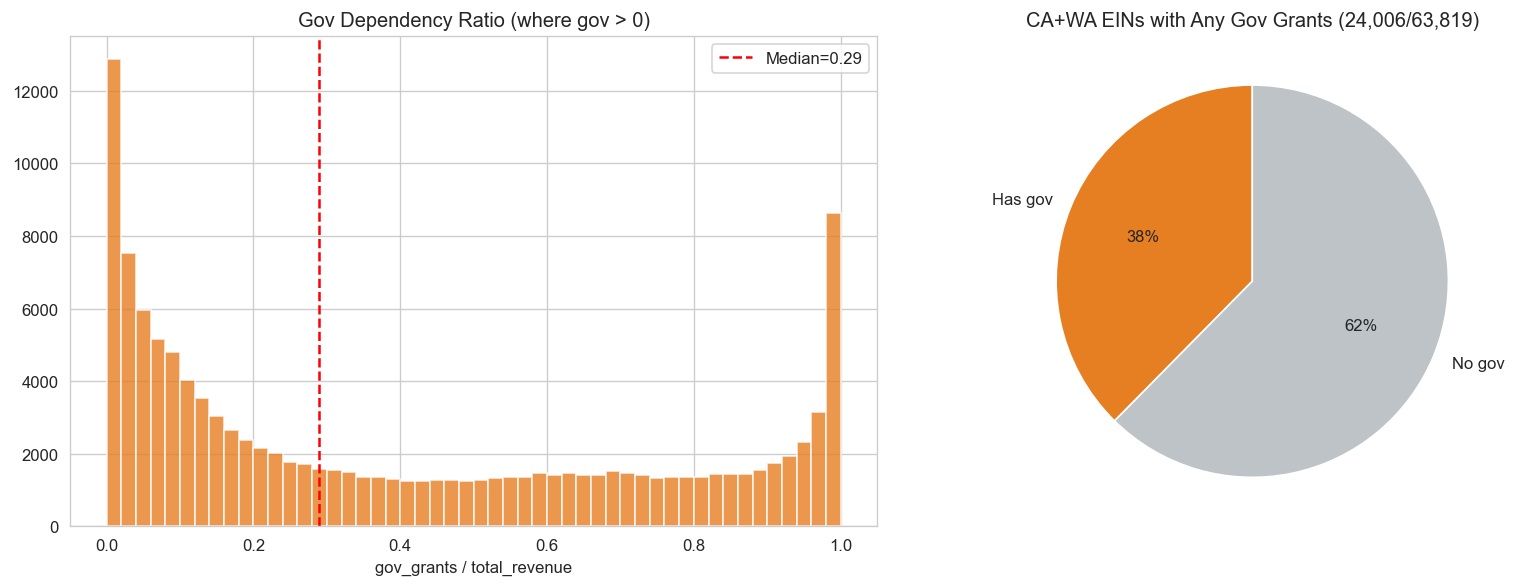

In [ ]:
# 4a — Gov dependency distribution

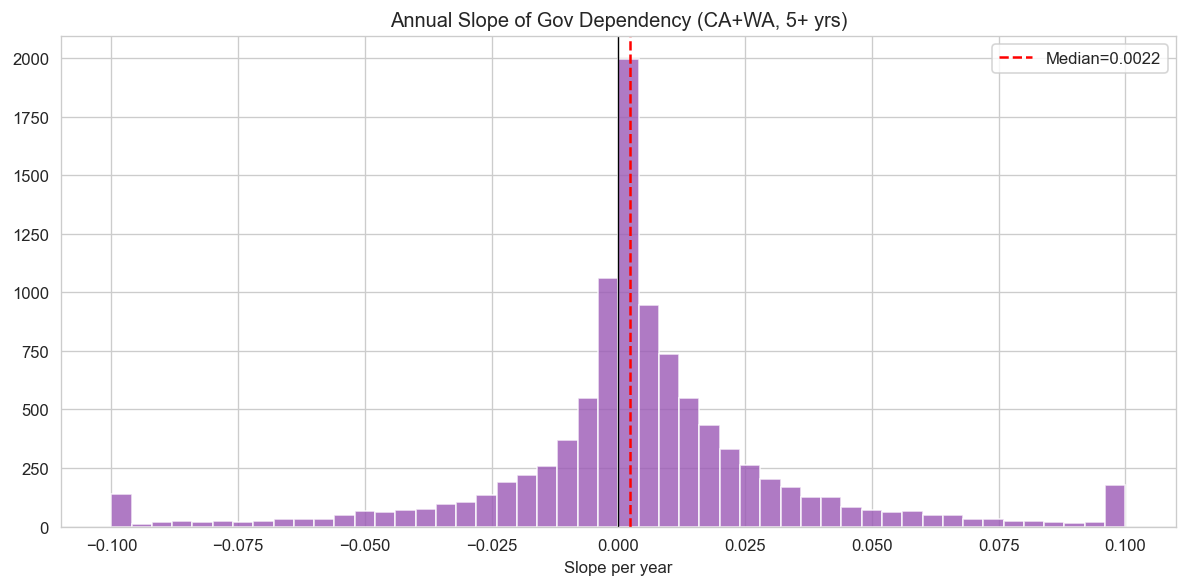

EINs with 5+ years of gov_dep data (CA+WA): 10,306
  Increasing: 4,365 (42.4%)
  Stable:     3,476 (33.7%)
  Decreasing: 2,465 (23.9%)


In [ ]:
# 4b — Gov dependency trend

---
## 5. Shock Absorption Months

If the largest revenue source dropped to zero, how many months of liquid-reserve runway remain?

CA+WA rows with liquid data: 451,580
Q25=1.8, Median=5.0, Q75=12.1
< 3 months: 160,943 (35.9%)
< 6 months: 247,884 (55.3%)


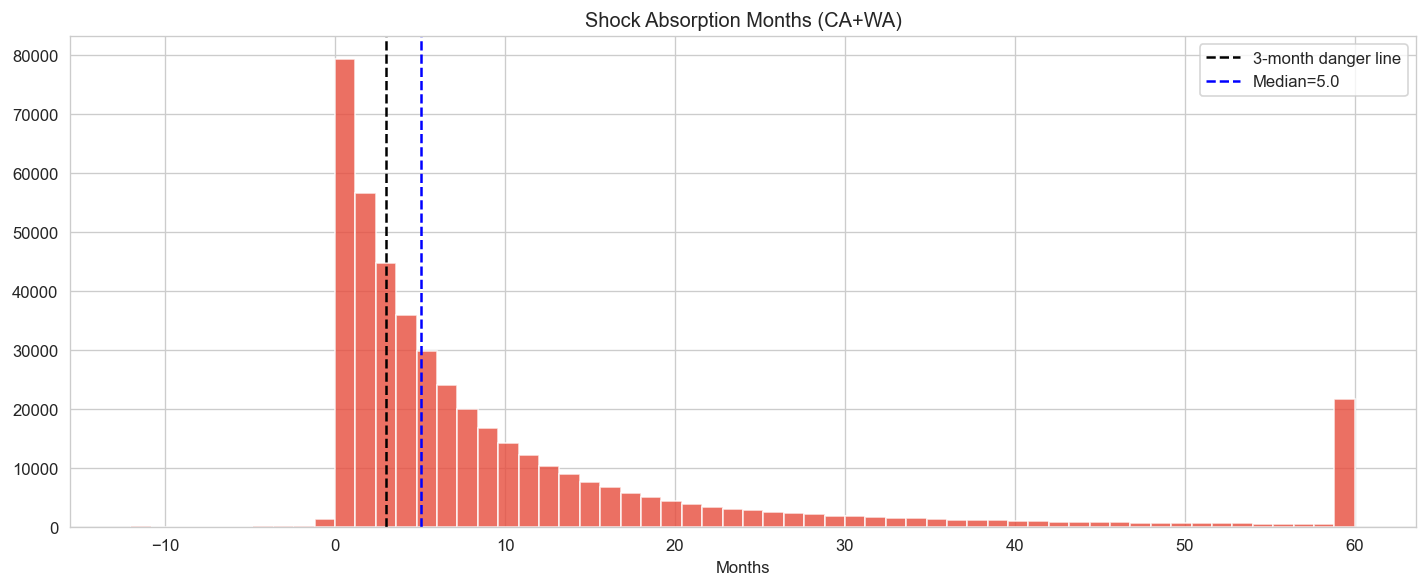


Largest revenue source distribution:
max_src
contributions_grants       235871
program_service_revenue    173283
other_revenue               30171
investment_income           12249
government_grants               6


In [ ]:
# 5 — Shock absorption

---
## 6. Recovery Analog Feasibility

Are there enough orgs that went from bottom-quartile to top-quartile resilience? Need >= 100 nationally.

In [ ]:
# 6 — Recovery analogs

EINs with data in both periods: 252,373
Pre Q25: 4.1 mo, Post Q75: 41.6 mo

Recovery analogs (national): 1,278
  PASS
Recovery analogs (CA+WA):    193

Examples:
  010274998 (ME):    3.4 ->  235.4 mo  Mount St Joseph
  010339744 (ME):    0.0 ->  119.7 mo  Lovell Historical Society
  010495219 (ME):  -31.0 ->   43.7 mo  BARAN PLACE CO CHARLES RANKIE
  010544705 (ME):    0.5 ->  332.8 mo  ST ANTHONYS MONASTERY ASSOCIATION
  020593101 (MA):  -27.4 ->   46.3 mo  LUTHERAN COMMUNITY SERVICES - CREATIVE LIVING INC

Improvement: median=106.4 mo, mean=3054.8 mo


---
## 7. Confidence Tier Distribution

How many CA/WA orgs get High / Medium / Low confidence labels?

- **High**: 5+ years, no missing core fields
- **Medium**: 3-4 years, or <=1 year with missing core field
- **Low**: <3 years or multiple years with missing core fields

CA+WA Confidence Tier Distribution:
    High:  21,333 EINs (33.4%)
  Medium:   8,415 EINs (13.2%)
     Low:  34,071 EINs (53.4%)
  Total:  63,819


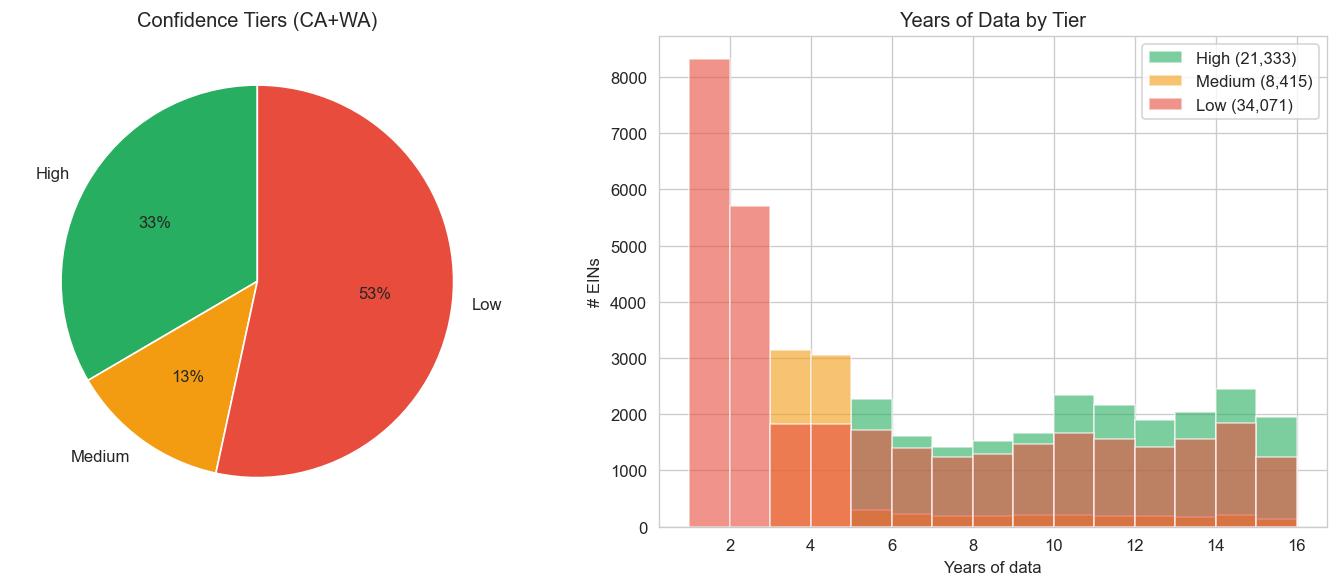


Median years by tier:
  High: 10 years
  Medium: 4 years
  Low: 4 years


In [ ]:
# 7 — Confidence tiers